In [34]:
import sys
import os

# Add the project root to Python's search path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Now import the dataframes
from scripts.data_loading import consumers, accounts, transactions, category_mapping

In [35]:
# individual consumer data
consumers.head()

,prism_consumer_id,evaluation_date,credit_score,DQ_TARGET
0,0,2021-09-01,726.0,0.0
1,1,2021-07-01,626.0,0.0
2,2,2021-05-01,680.0,0.0
3,3,2021-03-01,734.0,0.0
4,4,2021-10-01,676.0,0.0


In [36]:
# account information
accounts.head()

,prism_consumer_id,prism_account_id,account_type,balance_date,balance
0,3023,0,SAVINGS,2021-08-31,90.57
1,3023,1,CHECKING,2021-08-31,225.95
2,4416,2,SAVINGS,2022-03-31,15157.17
3,4416,3,CHECKING,2022-03-31,66.42
4,4227,4,CHECKING,2021-07-31,7042.90


In [37]:
# transactional data
transactions.head()

,prism_consumer_id,prism_transaction_id,category,amount,credit_or_debit,posted_date
0,3023,0,4,0.05,CREDIT,2021-04-16
1,3023,1,12,481.56,CREDIT,2021-04-30
2,3023,2,4,0.05,CREDIT,2021-05-16
3,3023,3,4,0.07,CREDIT,2021-06-16
4,3023,4,4,0.06,CREDIT,2021-07-16


In [38]:
# category mapping
category_mapping

,category_id,category
0,0,SELF_TRANSFER
1,1,EXTERNAL_TRANSFER
2,2,DEPOSIT
3,3,PAYCHECK
4,4,MISCELLANEOUS
5,5,PAYCHECK_PLACEHOLDER
6,6,REFUND
7,7,INVESTMENT_INCOME
8,8,OTHER_BENEFITS
9,9,UNEMPLOYMENT_BENEFITS


# Change the data type for date columns

In [39]:
import pandas as pd

accounts['balance_date'] = pd.to_datetime(accounts['balance_date'])
transactions['posted_date'] = pd.to_datetime(transactions['posted_date'])

### Delete duplications

In [40]:
# Check duplication across the four datasets
from collections import Counter

datasets = {
    'consumers': consumers,
    'accounts': accounts,
    'transactions': transactions,
    'category_mapping': category_mapping,
}

for name, df in datasets.items():
    print('\n' + '='*80)
    print(f'Dataset: {name} — rows: {len(df):,}, columns: {df.shape[1]}')

    # Full-row duplicates
    dup_any = df.duplicated(keep=False).sum()
    dup_prev = df.duplicated(keep='first').sum()
    unique_rows = df.drop_duplicates().shape[0]
    print(f'Full-row duplicates (any in group): {dup_any:,}')
    print(f'Full-row duplicates (excluding first in group): {dup_prev:,}')
    print(f'Unique rows after dropping duplicates: {unique_rows:,}')

    # Look for common ID columns and report duplicate IDs
    id_cols = [c for c in ['prism_consumer_id', 'prism_account_id', 'prism_transaction_id'] if c in df.columns]
    if id_cols:
        for col in id_cols:
            n_missing = df[col].isna().sum()
            n_dup_ids = df[col].duplicated().sum()
            n_unique_ids = df[col].nunique(dropna=True)
            print(f"\nColumn: {col} — missing: {n_missing:,}, duplicate id rows: {n_dup_ids:,}, unique ids: {n_unique_ids:,}")
            if n_dup_ids > 0:
                # show top duplicated ids
                top_dups = df[col].value_counts().head(5)
                print('Top duplicated ids (count):\n', top_dups.to_string())
    else:
        # For mapping tables, check duplicates on all columns
        if name == 'category_mapping':
            dup_map = df.duplicated(subset=df.columns.tolist(), keep=False).sum()
            print(f"Category mapping duplicate rows (any in group): {dup_map:,}")

    # Show a few example duplicate rows (full-row duplicates)
    if dup_any > 0:
        print('\nExample duplicate rows:')
        display(df[df.duplicated(keep=False)].head(10))

    print('\n' + '='*80)

print('\nDuplicate check complete.')



Dataset: consumers — rows: 15,000, columns: 4
Full-row duplicates (any in group): 0
Full-row duplicates (excluding first in group): 0
Unique rows after dropping duplicates: 15,000

Column: prism_consumer_id — missing: 0, duplicate id rows: 0, unique ids: 15,000


Dataset: accounts — rows: 24,466, columns: 5
Full-row duplicates (any in group): 0
Full-row duplicates (excluding first in group): 0
Unique rows after dropping duplicates: 24,466

Column: prism_consumer_id — missing: 0, duplicate id rows: 11,457, unique ids: 13,009
Top duplicated ids (count):
 prism_consumer_id
14525    25
13491    14
14294    13
5109     12
7074     12

Column: prism_account_id — missing: 0, duplicate id rows: 0, unique ids: 24,466


Dataset: transactions — rows: 6,405,309, columns: 6
Full-row duplicates (any in group): 0
Full-row duplicates (excluding first in group): 0
Unique rows after dropping duplicates: 6,405,309

Column: prism_consumer_id — missing: 0, duplicate id rows: 6,390,817, unique ids: 14,492


In [41]:
# Remove duplicate rows from `transactions` (prefer dedupe by transaction id when available)
print('\nRemoving duplicates from `transactions` dataframe...')

before = len(transactions)
if 'prism_transaction_id' in transactions.columns:
    dup_count = transactions['prism_transaction_id'].duplicated().sum()
    print(f'Found {dup_count:,} duplicate prism_transaction_id rows (including first occurrences).')
    transactions = (
        transactions.drop_duplicates(subset=['prism_transaction_id'], keep='first')
                    .reset_index(drop=True)
    )
    removed = before - len(transactions)
    print(f'Removed {removed:,} rows based on `prism_transaction_id` deduplication.')
else:
    dup_count = transactions.duplicated().sum()
    print(f'Found {dup_count:,} full-row duplicate rows.')
    transactions = transactions.drop_duplicates(keep='first').reset_index(drop=True)
    print(f'Removed {dup_count:,} full-row duplicates.')

# As an extra precaution, also remove exact duplicate rows (if any remain)
extra_dups = transactions.duplicated().sum()
if extra_dups > 0:
    transactions = transactions.drop_duplicates(keep='first').reset_index(drop=True)
    print(f'Also removed {extra_dups:,} additional exact duplicate rows.')

print(f'`transactions` now has {len(transactions):,} rows (was {before:,}).')

# Optionally show a quick sanity sample
print('\nSample rows after deduplication:')
print(transactions.head(3).to_string())



Removing duplicates from `transactions` dataframe...
Found 0 duplicate prism_transaction_id rows (including first occurrences).
Removed 0 rows based on `prism_transaction_id` deduplication.
`transactions` now has 6,405,309 rows (was 6,405,309).

Sample rows after deduplication:
   prism_consumer_id prism_transaction_id  category  amount credit_or_debit posted_date
0               3023                    0         4    0.05          CREDIT  2021-04-16
1               3023                    1        12  481.56          CREDIT  2021-04-30
2               3023                    2         4    0.05          CREDIT  2021-05-16


# Overall check with the dataset

In [42]:
# len of consumers
len(consumers)

15000

In [43]:
consumers['prism_consumer_id'].nunique()

15000

In [44]:
accounts['prism_consumer_id'].nunique()

13009

In [45]:
# intersection of consumer ids in accounts and consumers
len(set(consumers['prism_consumer_id']).intersection(set(accounts['prism_consumer_id'])))

13009

In [46]:
consumers['prism_consumer_id'].dtype

Int64Dtype()

# Check "DQ_TARGET" related

In [47]:
# check null
consumers['DQ_TARGET'].isnull().sum()

3000

In [48]:
# percentage of null DQ_TARGET
consumers['DQ_TARGET'].isnull().mean()

0.2

In [49]:
# export the untagged set
untagged = consumers[consumers['DQ_TARGET'].isnull()].copy()
untagged.to_csv('../output/untagged_consumers.csv', index=False)

In [50]:
# remove null DQ_TARGET
available_consumers = consumers[~consumers['DQ_TARGET'].isnull()]
available_consumers['DQ_TARGET'].value_counts()

DQ_TARGET
0.0    10994
1.0     1006
Name: count, dtype: int64

11000 consumers in our dataset are avaliable. 

In [51]:
# deliquency rate (within non-null DQ_TARGET)
available_consumers['DQ_TARGET'].value_counts()[1]/available_consumers['DQ_TARGET'].value_counts().sum()

0.08383333333333333

# Check things that might relate to 'DQ_TARGET'

## Consumer with zero or negative account balance

In [52]:
# accounts with balance <= 0
consumers_neg_bal = accounts[accounts['balance'] <= 0]['prism_consumer_id']
consumers_neg_bal.nunique()

1622

In [53]:
# check the DQ_TARGET for these consumers
dq_neg_bal = consumers[consumers['prism_consumer_id'].isin(consumers_neg_bal)]['DQ_TARGET']
dq_neg_bal.value_counts()


DQ_TARGET
0.0    1057
1.0     210
Name: count, dtype: int64

In [54]:
dq_neg_bal.isnull().sum()

355

In [55]:
# check the percentage of defaulted consumers with negative balance
dq_neg_bal.value_counts()[1]/dq_neg_bal.value_counts().sum()

0.16574585635359115

Consumer with zero to negative balance is more likely to default.

## Consumers with no transactions

In [56]:
# consumers with no tranactions
consumer_with_transactions = transactions['prism_consumer_id'].unique()
consumer_no_transactions = consumers[~consumers['prism_consumer_id'].isin(consumer_with_transactions)]
consumer_no_transactions.shape[0]

508

In [57]:
# intersection of consumer ids in transactions and consumers
len(set(consumers['prism_consumer_id']).intersection(set(transactions['prism_consumer_id'])))

14492

In [58]:
# dq target avaliable consumers with no tranactions
consumer_with_transactions = transactions['prism_consumer_id'].unique()
consumer_no_transactions = available_consumers[~available_consumers['prism_consumer_id'].isin(consumer_with_transactions)]
consumer_no_transactions.shape[0]

399

In [59]:
# percentage of consumers with no transactions
consumer_no_transactions.shape[0]/available_consumers.shape[0]

0.03325

In [60]:
# check the DQ_TARGET for these consumers
consumer_no_transactions['DQ_TARGET'].value_counts()


DQ_TARGET
0.0    341
1.0     58
Name: count, dtype: int64

In [61]:
# DQ rate
consumer_no_transactions['DQ_TARGET'].value_counts()[1]/consumer_no_transactions['DQ_TARGET'].value_counts().sum()

0.14536340852130325

## Check account types

In [62]:
accounts["account_type"].unique()

<ArrowStringArray>
[        'SAVINGS',        'CHECKING',     'CREDIT CARD',  'LINE OF CREDIT',
     'MONEYMARKET',            'LOAN',    'MONEY MARKET',            'ROTH',
        'MORTGAGE',      'RETIREMENT',         'PREPAID',       'BROKERAGE',
        'CONSUMER',              'CD',             'IRA',            'AUTO',
         'STUDENT',             'HSA', 'CASH MANAGEMENT',           'OTHER',
            '401K',      'STOCK PLAN',       'OVERDRAFT',     'HOME EQUITY']
Length: 24, dtype: str

In [63]:
accounts[accounts["account_type"] == "CREDIT CARD"]

,prism_consumer_id,prism_account_id,account_type,balance_date,balance
9186,7950,9186,CREDIT CARD,2023-01-07,428.68
15468,5247,15468,CREDIT CARD,2023-07-21,0.00
16985,14567,16985,CREDIT CARD,2022-01-12,3519.99
17013,13350,17013,CREDIT CARD,2022-02-20,54.24
17016,13954,17016,CREDIT CARD,2021-12-08,0.00
...,...,...,...,...,...
24412,10580,24412,CREDIT CARD,2022-03-10,629.57
24413,10580,24413,CREDIT CARD,2022-03-10,5633.86
24416,13439,24416,CREDIT CARD,2022-03-09,29.99
24425,13214,24425,CREDIT CARD,2021-12-10,58.24


# Check holdout set

In [64]:
# untagged consumers with no transactions
untagged_no_transactions = untagged[~untagged['prism_consumer_id'].isin(consumer_with_transactions)]
untagged_no_transactions.shape[0]

109

In [65]:
feature = pd.read_csv('../output/features.csv')
feature['DQ_TARGET'].isna().sum()

3000

Saved → ../output/eda_consumer_population.png


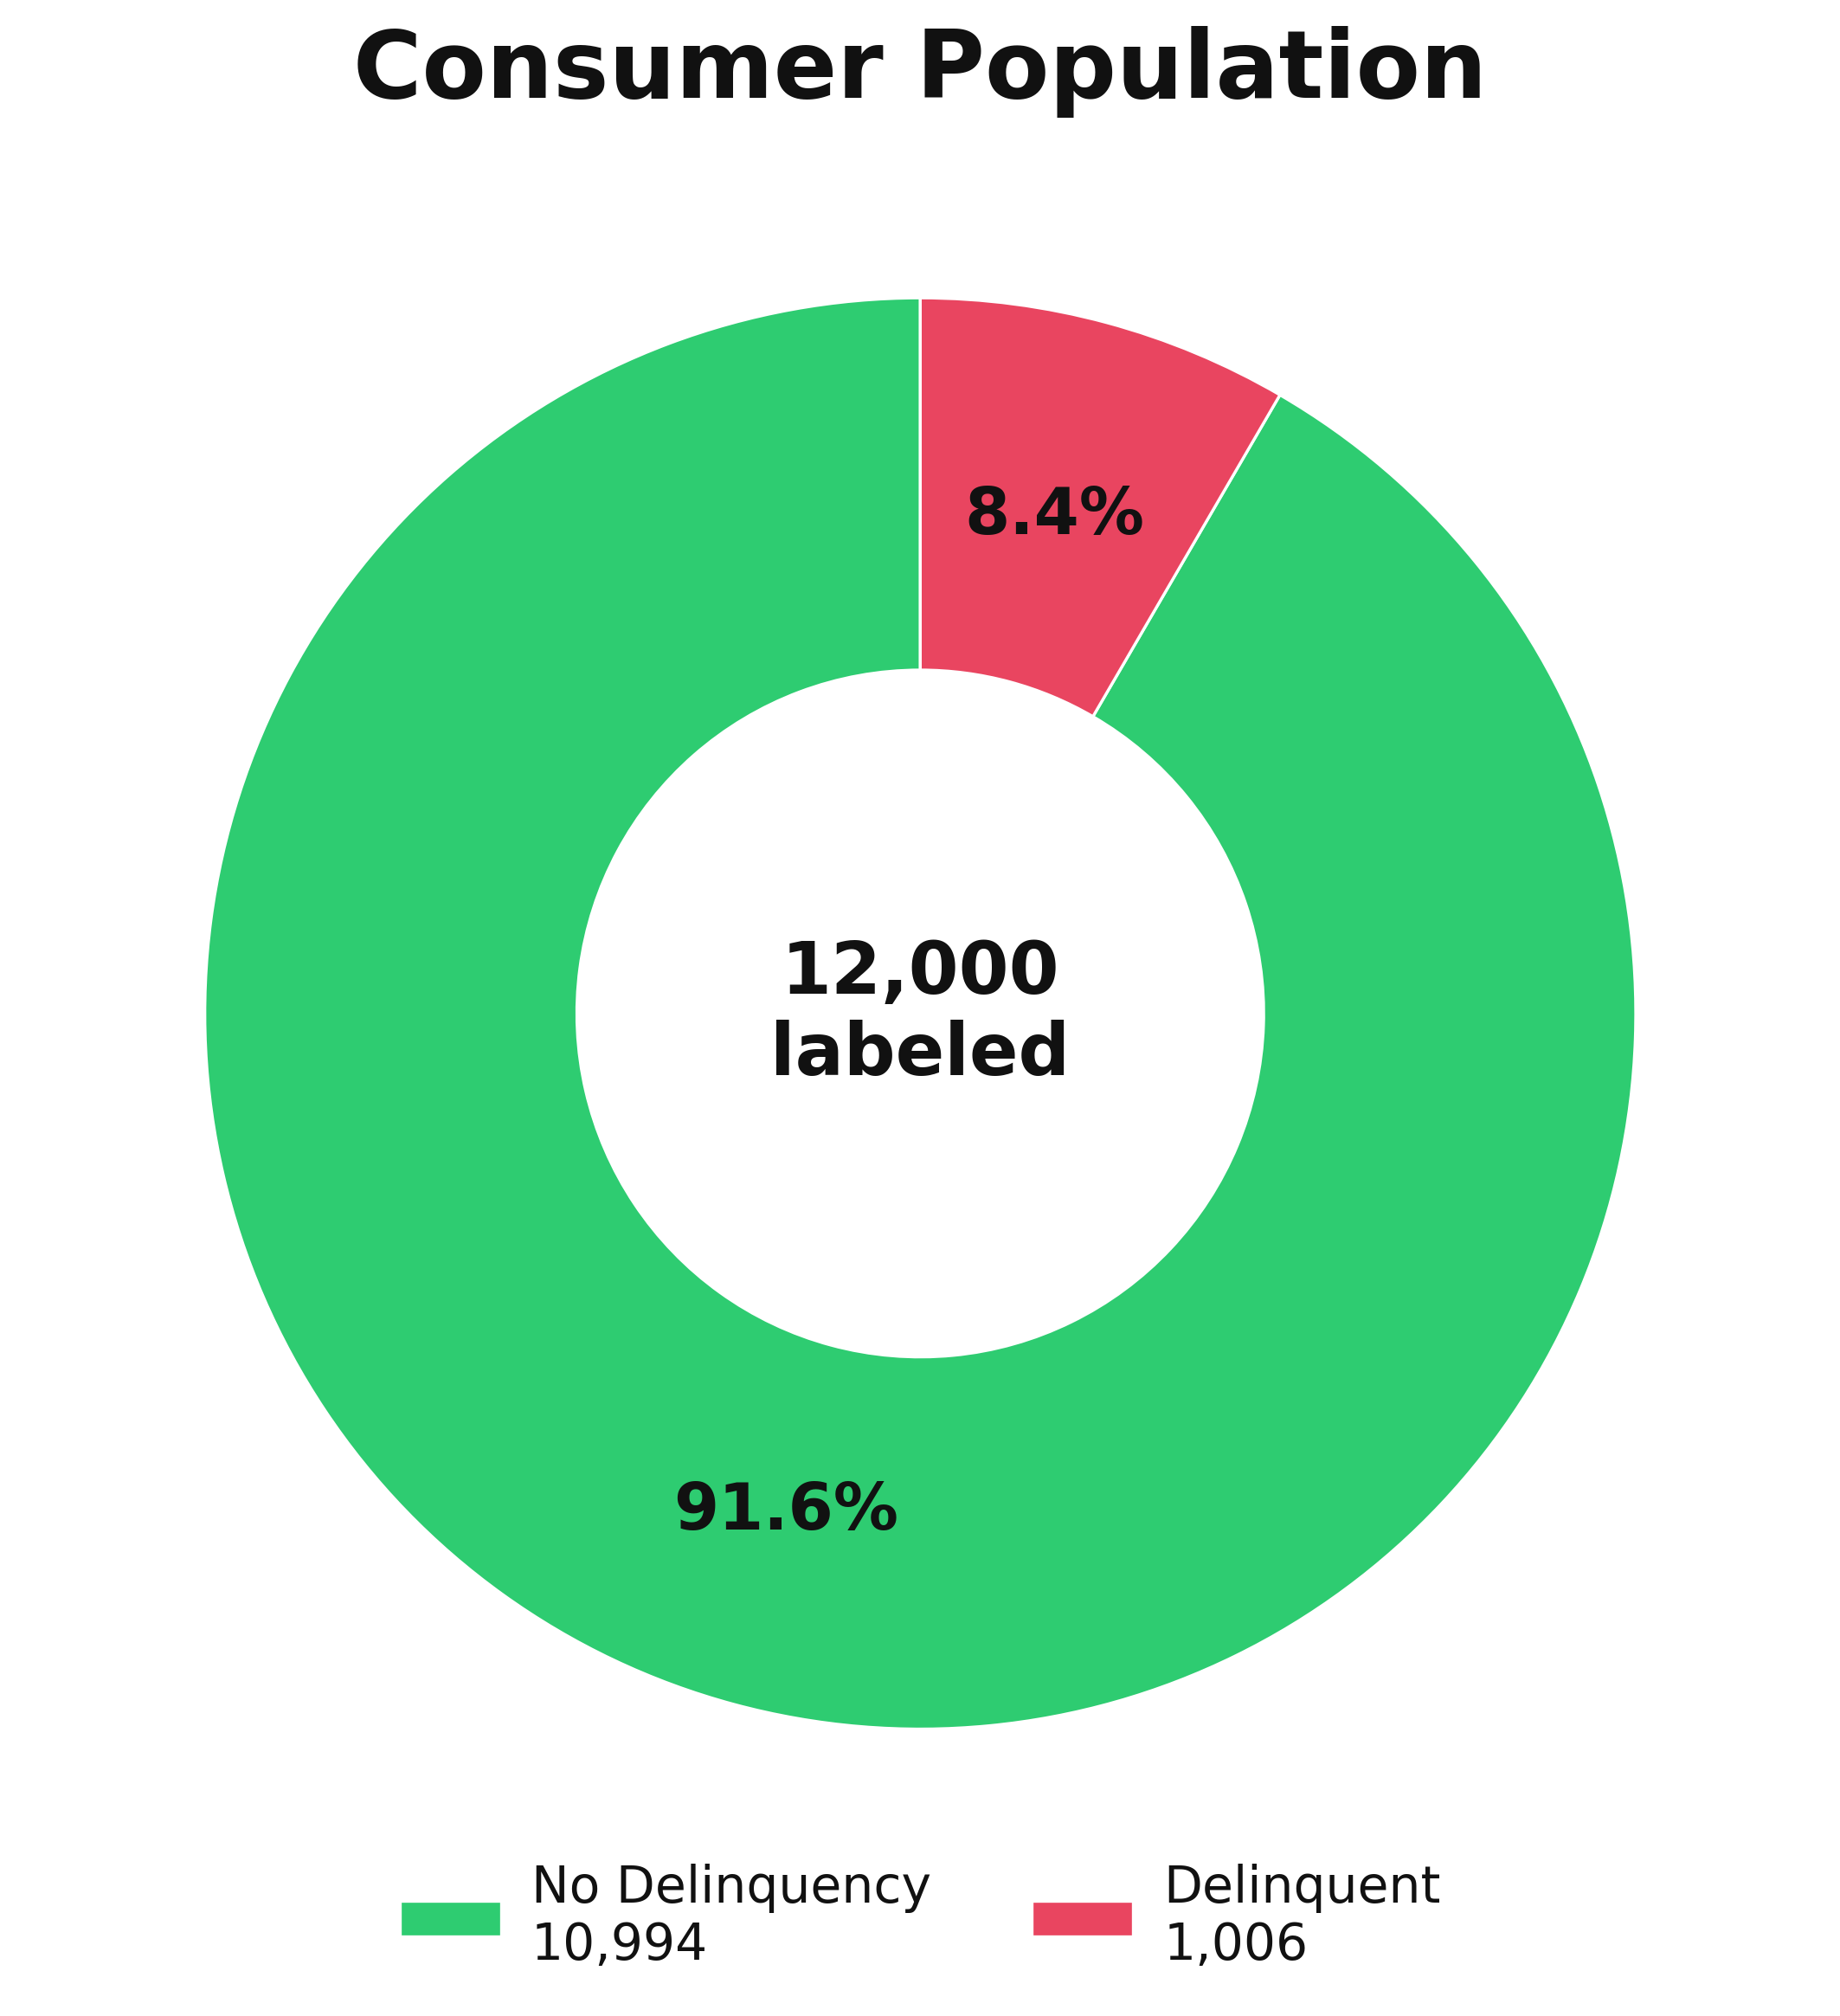

In [92]:
import matplotlib.pyplot as plt
import numpy as np

# Use transparent outputs for poster (white background)
CARD_BG = 'none'
TEXT    = '#111111'
GRID    = '#dddddd'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'text.color': TEXT,
    'axes.labelcolor': TEXT,
    'xtick.color': TEXT,
    'ytick.color': TEXT,
})

tagged  = available_consumers['DQ_TARGET'].value_counts()
n_non_dq = int(tagged[0])
n_dq     = int(tagged[1])
total_labeled = n_non_dq + n_dq

# ── Consumer Population Donut (poster-sized fonts) ──────────────────────────
fig1, ax1 = plt.subplots(figsize=(7, 10), dpi=300, facecolor='none')
ax1.set_facecolor(CARD_BG)

sizes  = [n_non_dq, n_dq]
colors = ['#2ecc71', '#e94560']
labels = [f'No Delinquency\n{n_non_dq:,}', f'Delinquent\n{n_dq:,}']

wedges, texts, autotexts = ax1.pie(
    sizes, colors=colors, autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=0.8),
    pctdistance=0.72,
)
for at in autotexts:
    at.set_fontsize(18)
    at.set_color(TEXT)
    at.set_fontweight('bold')
for t in texts:
    t.set_fontsize(16)
    t.set_color(TEXT)

# place legend directly under pie but close to it
ax1.legend(wedges, labels, loc='lower center', bbox_to_anchor=(0.5, -0.06),
           fontsize=14, frameon=False, ncol=2, handletextpad=0.6)
ax1.set_title('Consumer Population', fontsize=26, fontweight='bold',
              color=TEXT, pad=6)
ax1.text(0, 0, f'{total_labeled:,}\nlabeled', ha='center', va='center',
         fontsize=20, color=TEXT, fontweight='bold')

# tighten layout and reduce margins
plt.subplots_adjust(left=0.12, right=0.98, top=0.92, bottom=0.12)
plt.tight_layout(pad=0.4)
plt.savefig('../output/eda_consumer_population.png', dpi=300, bbox_inches='tight', pad_inches=0.02, transparent=True)
print("Saved → ../output/eda_consumer_population.png")
plt.show()


Saved → ../output/eda_account_types.png


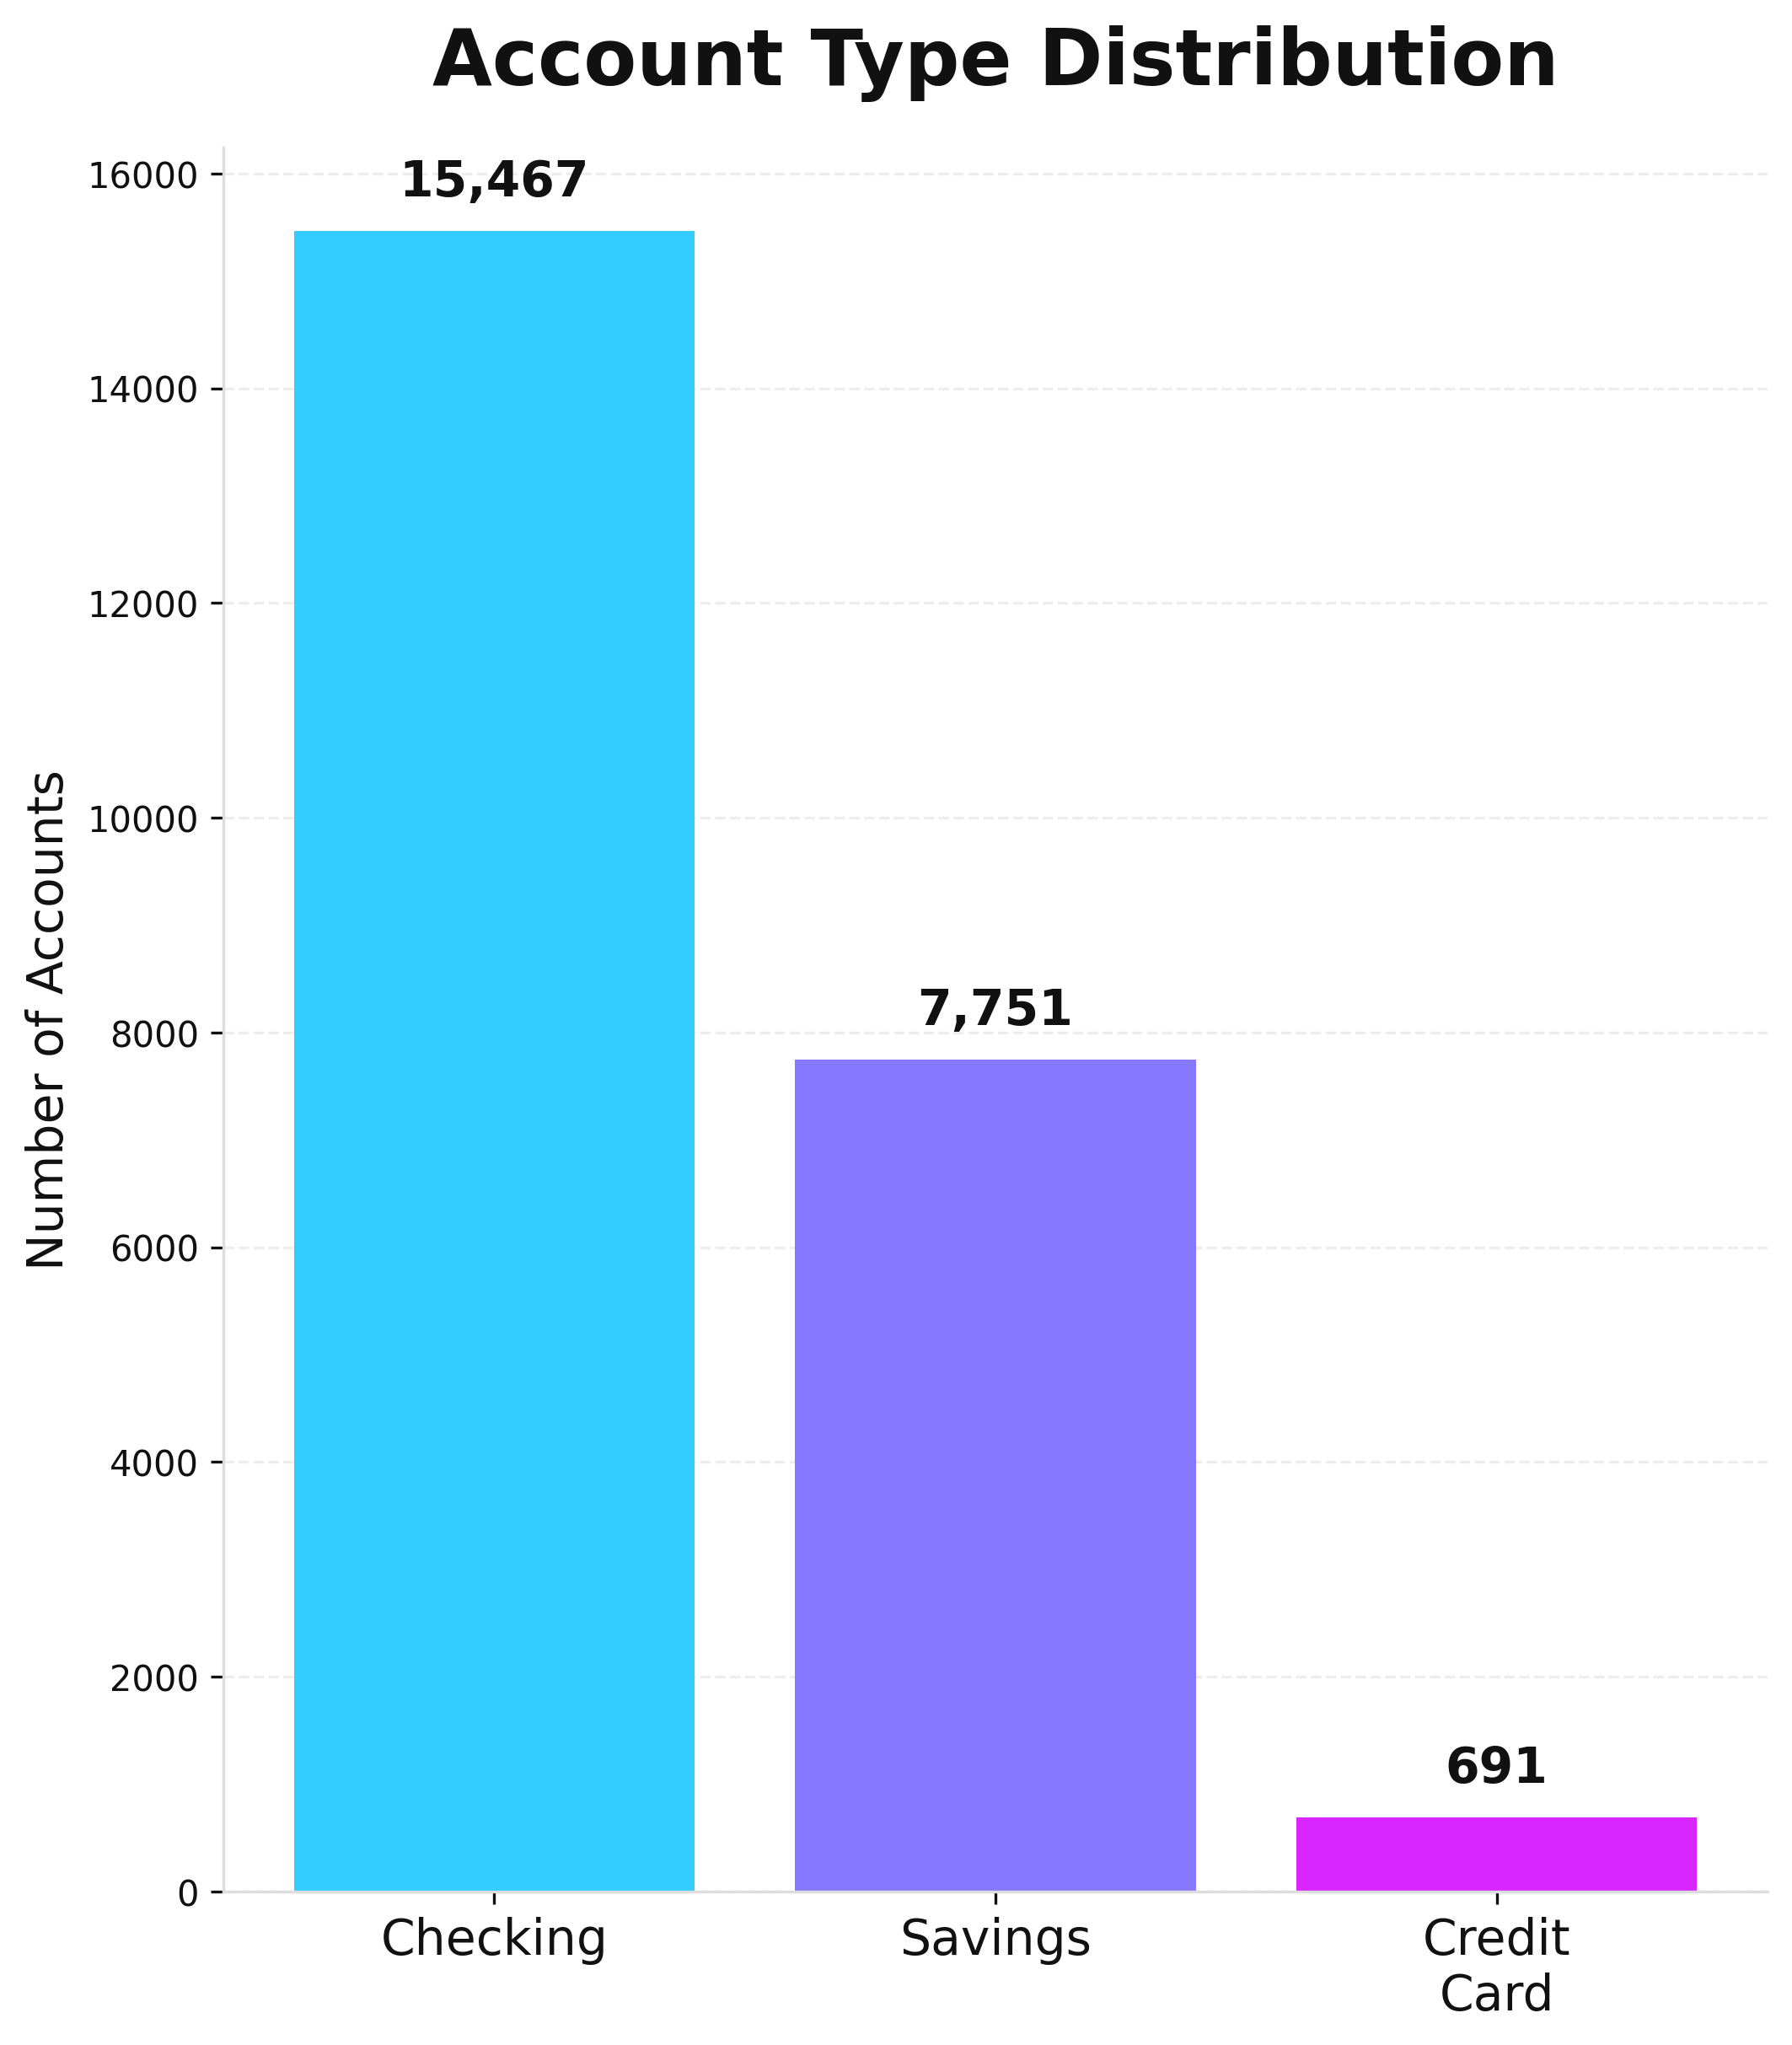

In [94]:
account_type_counts = accounts["account_type"].value_counts()

# ── Account Type Distribution (poster-sized fonts, more title spacing) ───────
fig2, ax3 = plt.subplots(figsize=(7, 8), dpi=300, facecolor='none')
ax3.set_facecolor('none')

top_types = account_type_counts.head(3)
bar_cols  = plt.cm.cool(np.linspace(0.2, 0.85, len(top_types)))
b3 = ax3.bar(range(len(top_types)), top_types.values, color=bar_cols,
             edgecolor='none', linewidth=0.6)

max_val = top_types.values.max()
for bar, val in zip(b3, top_types.values):
    ax3.text(bar.get_x() + bar.get_width() / 2, val + max_val * 0.015,
             f'{val:,}', ha='center', va='bottom', fontsize=14, color=TEXT, fontweight='bold')

labels_3 = [t.title().replace(' ', '\n') for t in top_types.index]
ax3.set_xticks(range(len(top_types)))
ax3.set_xticklabels(labels_3, fontsize=14, color=TEXT)
ax3.set_ylabel('Number of Accounts', fontsize=14, color=TEXT)
ax3.set_title('Account Type Distribution', fontsize=22, fontweight='bold', color=TEXT, pad=18)

# reduce whitespace around axes
ax3.spines[['top', 'right']].set_visible(False)
ax3.spines[['bottom', 'left']].set_color(GRID)
ax3.yaxis.grid(True, color=GRID, linestyle='--', alpha=0.5)
ax3.set_axisbelow(True)

plt.subplots_adjust(left=0.10, right=0.98, top=0.88, bottom=0.12)
plt.tight_layout(pad=0.4)
plt.savefig('../output/eda_account_types.png', dpi=300, bbox_inches='tight', pad_inches=0.02, transparent=True)
print("Saved → ../output/eda_account_types.png")
plt.show()


Saved → ../output/eda_balance_over_time.png


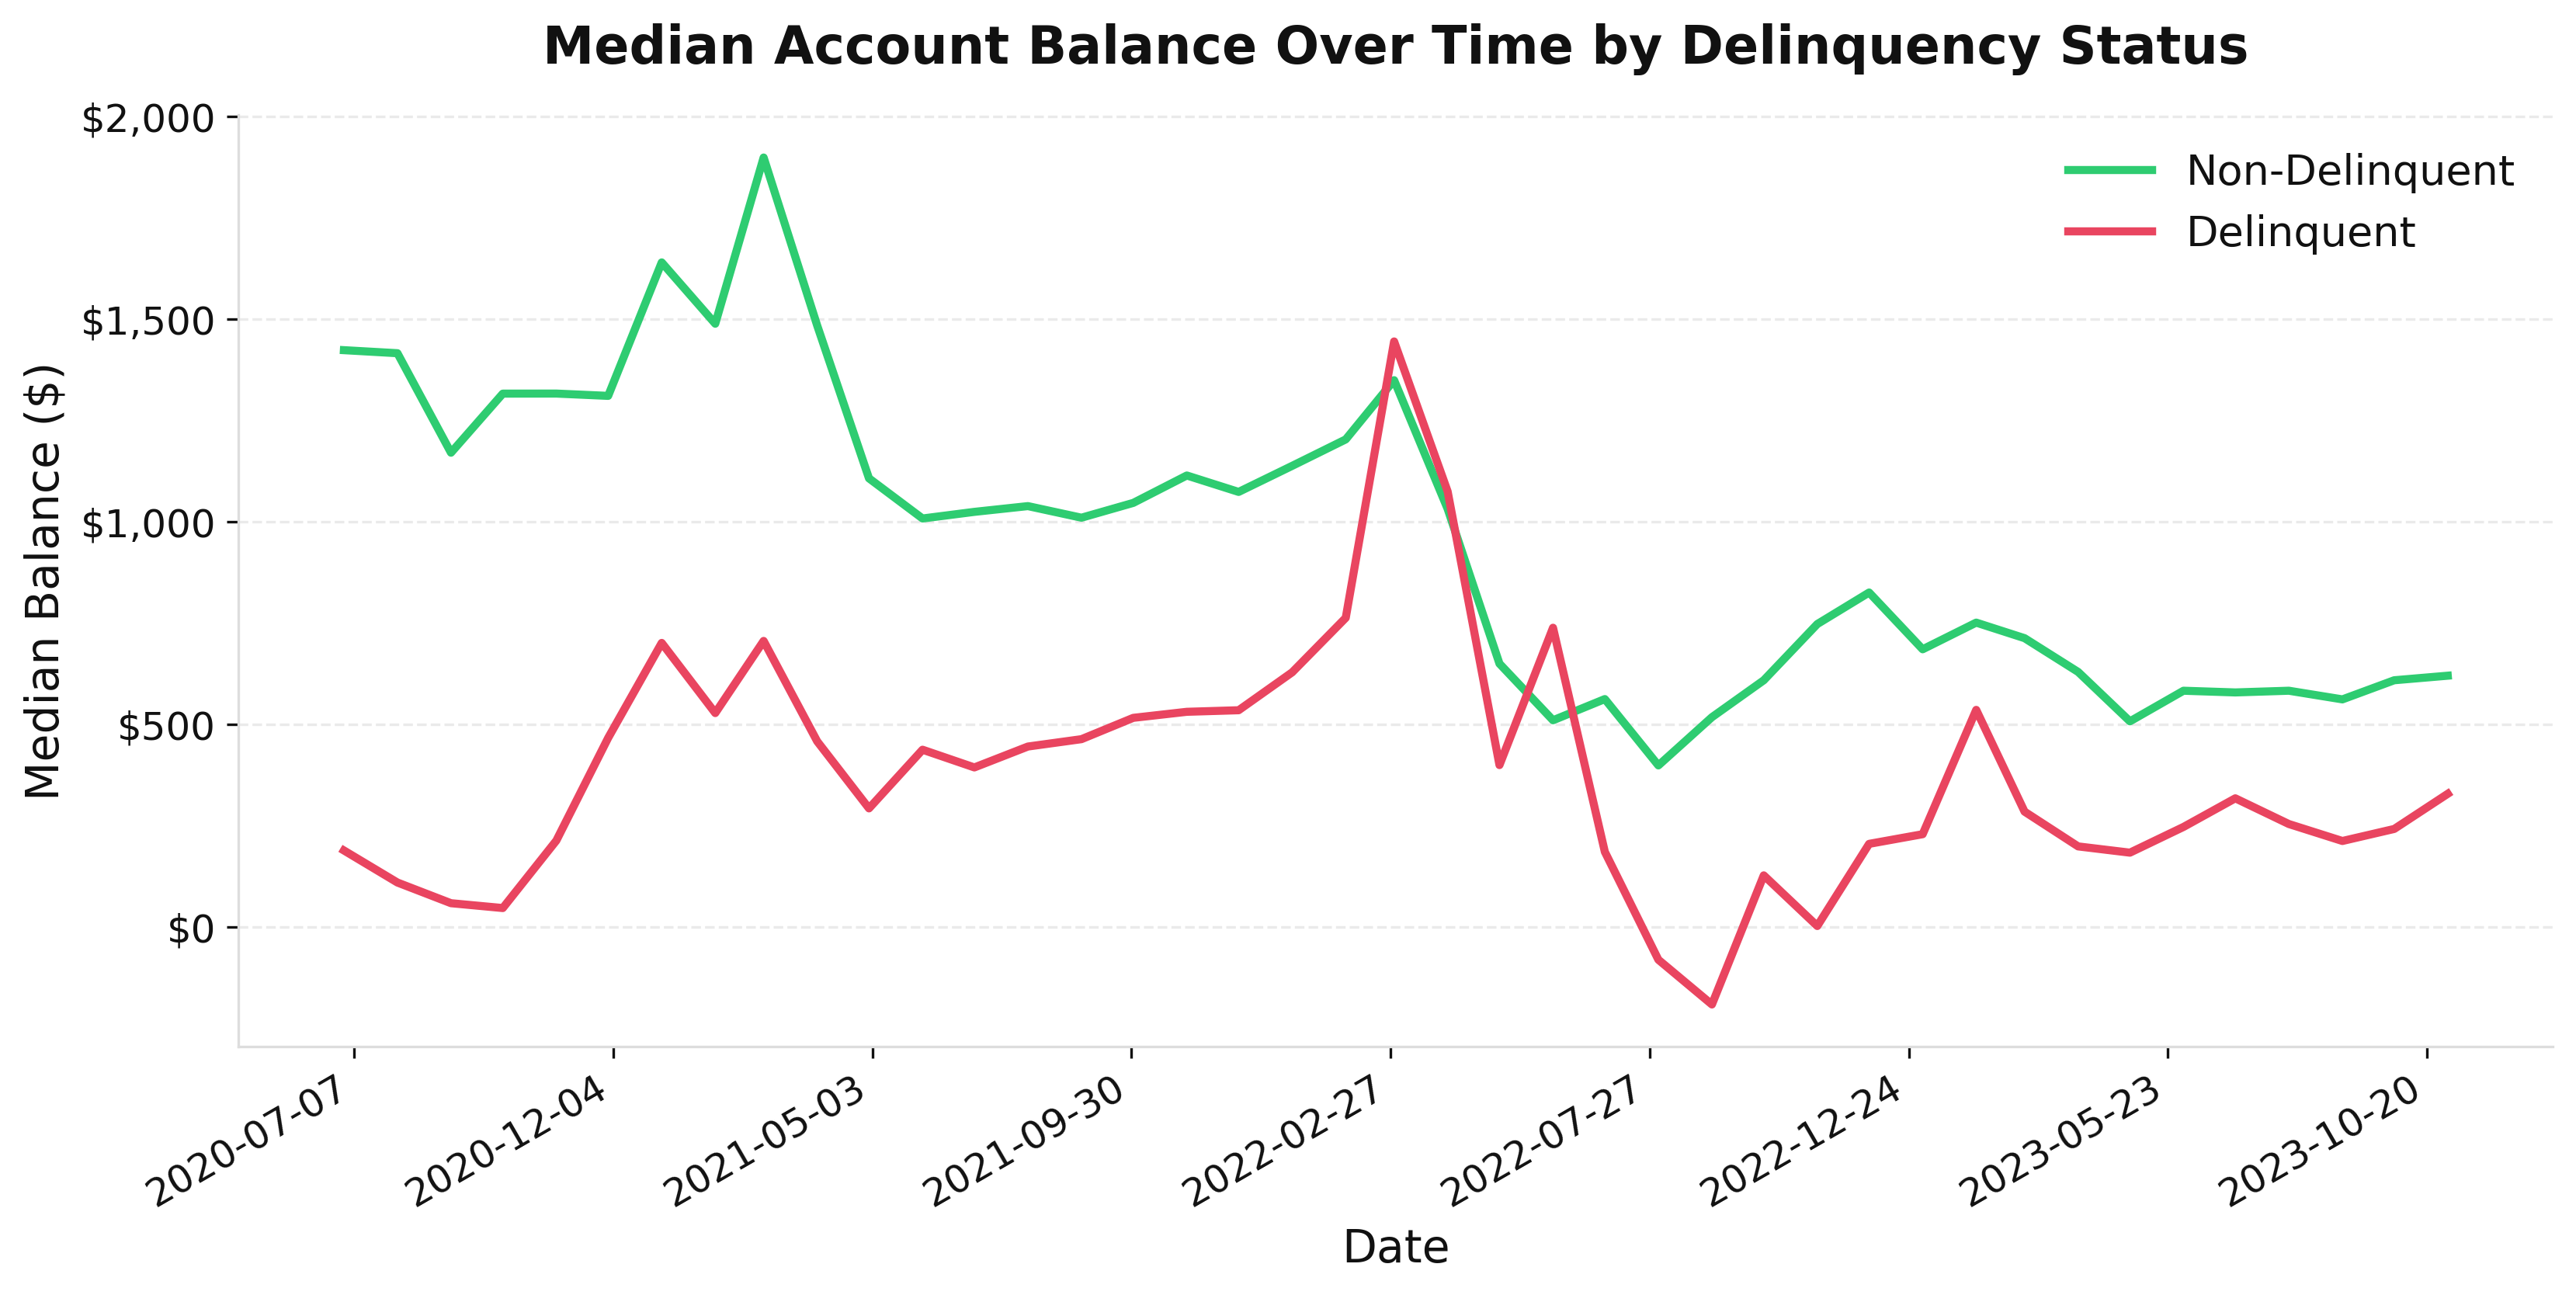

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Load data ────────────────────────────────────────────────────────────────
bf = pd.read_csv('../output/feature_creation_backfill_df.csv', parse_dates=['date'])
bf = bf[bf['DQ_TARGET'].notna()].copy()
bf['DQ_TARGET'] = bf['DQ_TARGET'].astype(int)

# Monthly median balance per group
bf['month'] = bf['date'].dt.to_period('M')
monthly = (
    bf.groupby(['month', 'DQ_TARGET'])['balance']
      .median()
      .reset_index()
)
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

# Cut to the last month where BOTH groups have data
last_common = min(
    monthly[monthly['DQ_TARGET'] == 0]['month_dt'].max(),
    monthly[monthly['DQ_TARGET'] == 1]['month_dt'].max(),
)
monthly = monthly[monthly['month_dt'] <= last_common]

dq0 = monthly[monthly['DQ_TARGET'] == 0].sort_values('month_dt')
dq1 = monthly[monthly['DQ_TARGET'] == 1].sort_values('month_dt')

# ── Plot ─────────────────────────────────────────────────────────────────────
TEXT = '#111111'
GRID = '#dddddd'

fig, ax = plt.subplots(figsize=(11, 5.5), dpi=300, facecolor='none')
ax.set_facecolor('none')

ax.plot(dq0['month_dt'], dq0['balance'],
        color='#2ecc71', linewidth=2.5, label='Non-Delinquent')
ax.plot(dq1['month_dt'], dq1['balance'],
        color='#e94560', linewidth=2.5, label='Delinquent')

# Formatting
ax.set_xlabel('Date', fontsize=14, color=TEXT)
ax.set_ylabel('Median Balance ($)', fontsize=14, color=TEXT)
ax.set_title('Median Account Balance Over Time by Delinquency Status',
             fontsize=16, fontweight='bold', color=TEXT, pad=16)

ax.tick_params(axis='both', labelsize=12, colors=TEXT)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_locator(mticker.MaxNLocator(10))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_color(GRID)
ax.yaxis.grid(True, color=GRID, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

ax.legend(fontsize=13, frameon=False, loc='upper right')

plt.tight_layout(pad=0.5)
plt.savefig('../output/eda_balance_over_time.png', dpi=300,
            bbox_inches='tight', pad_inches=0.04, transparent=True)
print("Saved → ../output/eda_balance_over_time.png")
plt.show()
